In [120]:
try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder,
    OrdinalEncoder
)
    import joblib
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import OneHotEncoder
    from sklearn.preprocessing import OrdinalEncoder
    from sklearn.model_selection import train_test_split
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import(
        mean_absolute_error,
        mean_squared_error,
        r2_score

   )
    from sklearn.model_selection import GridSearchCV
    from sklearn.model_selection import cross_val_score
    from sklearn.tree import DecisionTreeRegressor
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.ensemble import (
        GradientBoostingRegressor,
        AdaBoostRegressor,

    )

    from scipy.stats import f_oneway
    import warnings
    warnings.filterwarnings("ignore")
    print("All libraries imported successfully.")
except ImportError as e:
    print(f"Error importing libraries: {e}")


All libraries imported successfully.


In [121]:
try:
    data = pd.read_csv(r'C:\Users\akash\OneDrive\Documents\ML project\Used Car Price Estimation\Data\used_car_price_dataset_extended.csv')
    print("Data loaded successfully.")
except FileNotFoundError:
    print("Error: The file 'used_car_price_dataset_extended.csv' was not found.")

Data loaded successfully.


## Data understanding

In [122]:
data.shape

(10000, 12)

In [123]:
data.columns

Index(['make_year', 'mileage_kmpl', 'engine_cc', 'fuel_type', 'owner_count',
       'price_usd', 'brand', 'transmission', 'color', 'service_history',
       'accidents_reported', 'insurance_valid'],
      dtype='str')

In [124]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           10000 non-null  int64  
 1   mileage_kmpl        10000 non-null  float64
 2   engine_cc           10000 non-null  int64  
 3   fuel_type           10000 non-null  str    
 4   owner_count         10000 non-null  int64  
 5   price_usd           10000 non-null  float64
 6   brand               10000 non-null  str    
 7   transmission        10000 non-null  str    
 8   color               10000 non-null  str    
 9   service_history     7962 non-null   str    
 10  accidents_reported  10000 non-null  int64  
 11  insurance_valid     10000 non-null  str    
dtypes: float64(2), int64(4), str(6)
memory usage: 1.2 MB


In [125]:
data.describe()

,make_year,mileage_kmpl,engine_cc,owner_count,price_usd,accidents_reported
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2009.206900,17.960753,2287.130000,3.003500,7179.754532,0.492200
std,8.373858,5.025486,1291.276927,1.418904,2795.270940,0.694109
min,1995.000000,5.000000,800.000000,1.000000,1000.000000,0.000000
25%,2002.000000,14.540000,1200.000000,2.000000,5176.547500,0.000000
50%,2009.000000,17.970000,1800.000000,3.000000,6961.260000,0.000000
75%,2016.000000,21.352500,3000.000000,4.000000,8993.732500,1.000000
max,2023.000000,35.000000,5000.000000,5.000000,17647.630000,5.000000


In [126]:
data[data["price_usd"] == data["price_usd"].max()]

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid
5173,2015,25.36,5000,Electric,1,17647.63,Hyundai,Manual,White,Full,1,Yes


In [127]:
for column in data.columns:
    print(f"Number of missing values in column '{column}'")
    print(f"Column: {column}")
    print(data[column].isnull().sum())
    print("__________________________________________________")

Number of missing values in column 'make_year'
Column: make_year
0
__________________________________________________
Number of missing values in column 'mileage_kmpl'
Column: mileage_kmpl
0
__________________________________________________
Number of missing values in column 'engine_cc'
Column: engine_cc
0
__________________________________________________
Number of missing values in column 'fuel_type'
Column: fuel_type
0
__________________________________________________
Number of missing values in column 'owner_count'
Column: owner_count
0
__________________________________________________
Number of missing values in column 'price_usd'
Column: price_usd
0
__________________________________________________
Number of missing values in column 'brand'
Column: brand
0
__________________________________________________
Number of missing values in column 'transmission'
Column: transmission
0
__________________________________________________
Number of missing values in column 'color'
Colum

In [128]:
a = 10000
b=2038
print(a-b)

7962


In [129]:
data[data['service_history'].isnull()]

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid
0,2001,8.17,4000,Petrol,4,8587.64,Chevrolet,Manual,White,NaN,0,No
1,2014,17.59,1500,Petrol,4,5943.50,Honda,Manual,Black,NaN,0,Yes
7,2015,17.46,2000,Diesel,5,7701.84,BMW,Manual,Blue,NaN,0,Yes
10,2013,21.25,1800,Petrol,2,10070.16,BMW,Automatic,Red,NaN,0,No
16,1998,27.29,1800,Petrol,3,6491.29,Tesla,Automatic,Gray,NaN,2,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
9981,2010,15.06,2500,Diesel,2,7897.16,Nissan,Automatic,Silver,NaN,0,Yes
9984,1997,14.60,1500,Petrol,4,2123.68,Hyundai,Manual,Silver,NaN,1,No
9985,2018,16.44,1800,Electric,1,9336.96,Chevrolet,Manual,Gray,NaN,0,Yes
9993,2004,17.95,2000,Petrol,2,5617.77,Volkswagen,Manual,Blue,NaN,0,Yes


In [130]:
data[data['accidents_reported']==5]

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid
8590,2018,16.29,1000,Petrol,4,5395.88,Hyundai,Automatic,Silver,Full,5,Yes
9243,2020,18.38,1800,Diesel,1,9186.39,Kia,Automatic,Blue,Partial,5,Yes


### Target Variable Analysis

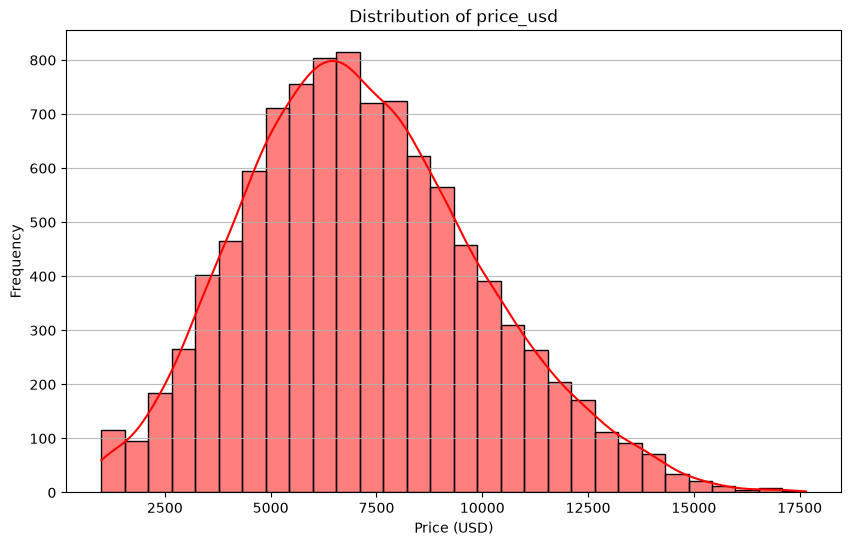

In [131]:
plt.figure(figsize=(10, 6))
sns.histplot(data["price_usd"], bins=30, kde=True,color='red', edgecolor='black')
plt.title("Distribution of price_usd")
plt.xlabel("Price (USD)")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.85)
plt.show()


### univariate analysis

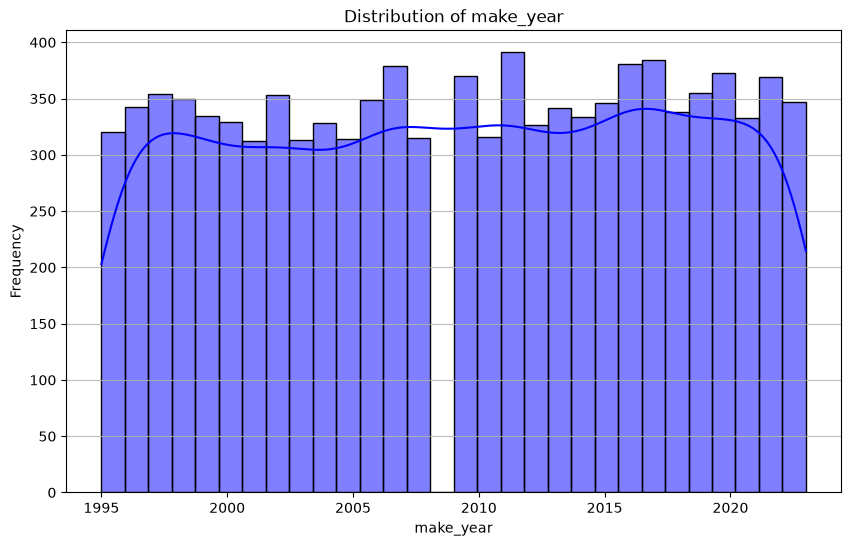

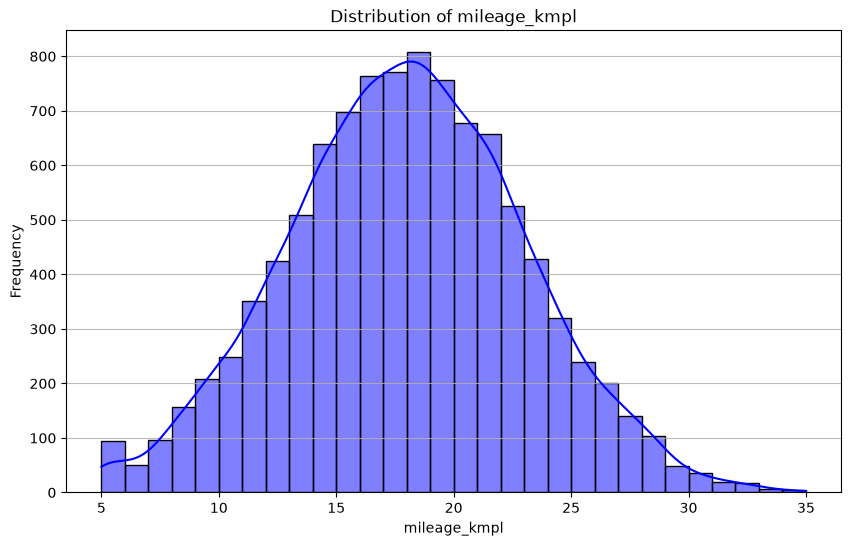

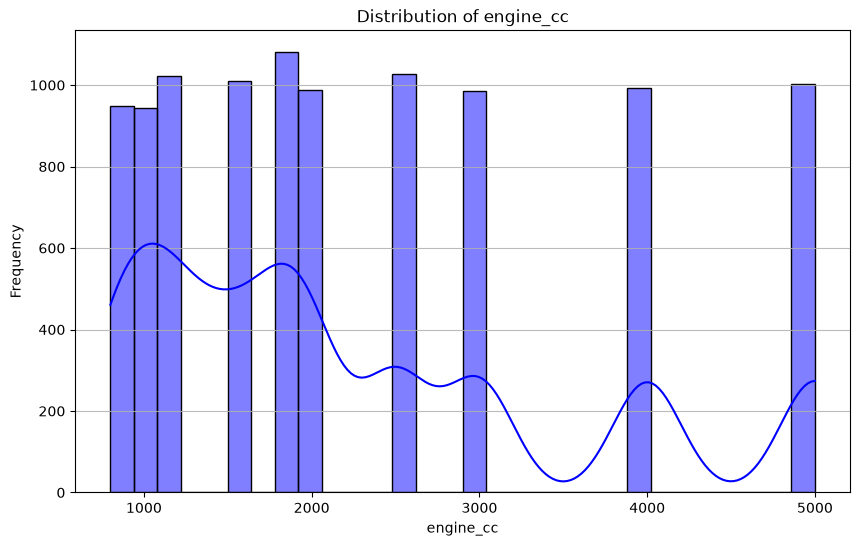

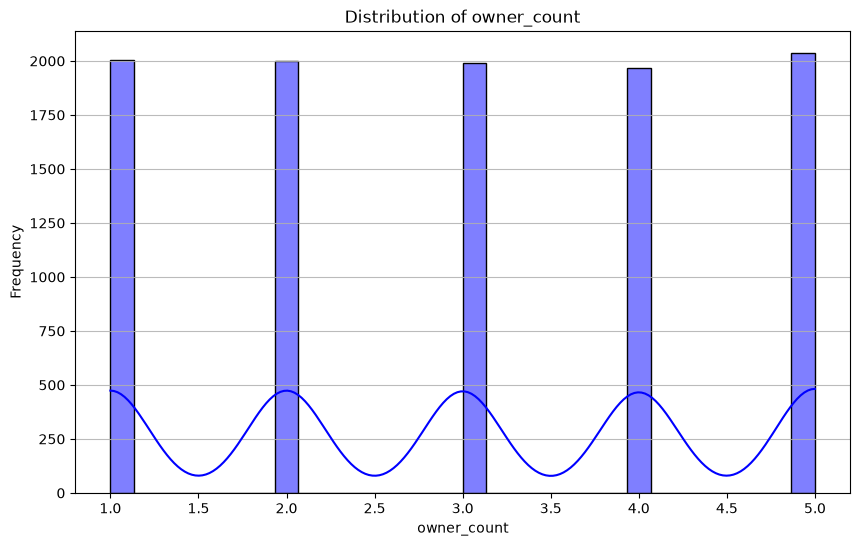

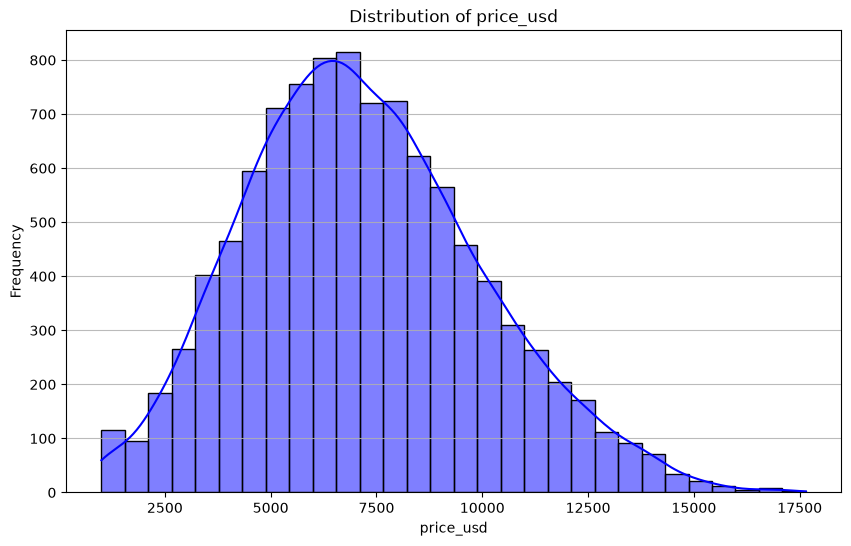

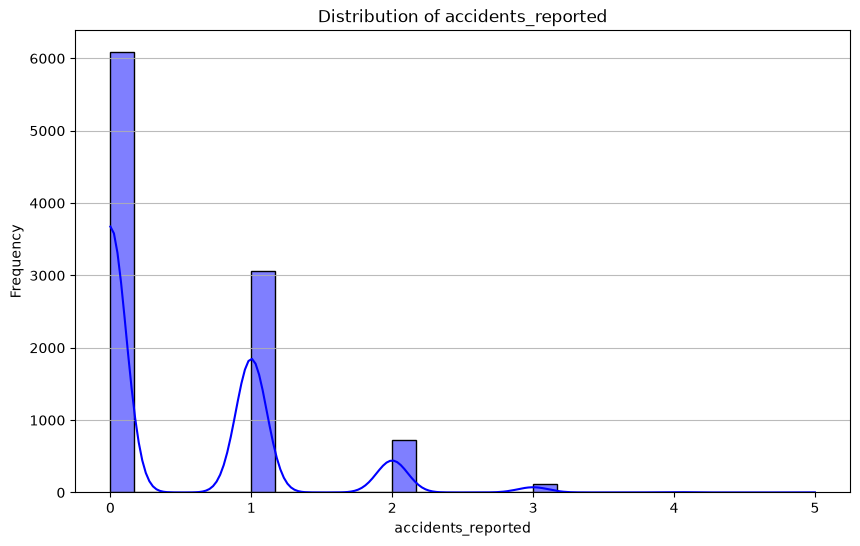

In [132]:
for column in data.select_dtypes(include=['number']).columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(data[column], bins=30, kde=True, color='blue', edgecolor='black')
    plt.title(f"Distribution of {column}")
    plt .xlabel(f"{column}")
    plt.ylabel("Frequency")
    plt.grid(axis='y', alpha=0.85)
    plt.show()

Countplot for column: fuel_type
-------------------


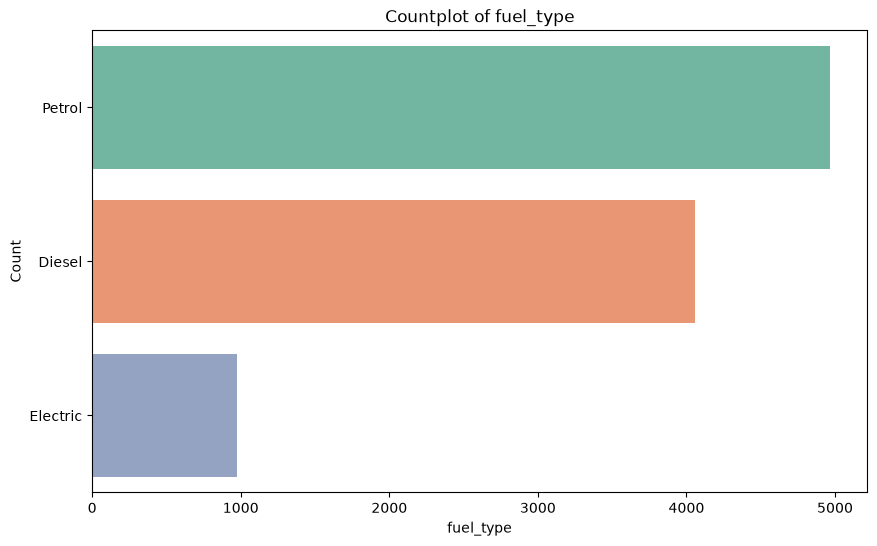

Countplot for column: brand
-------------------


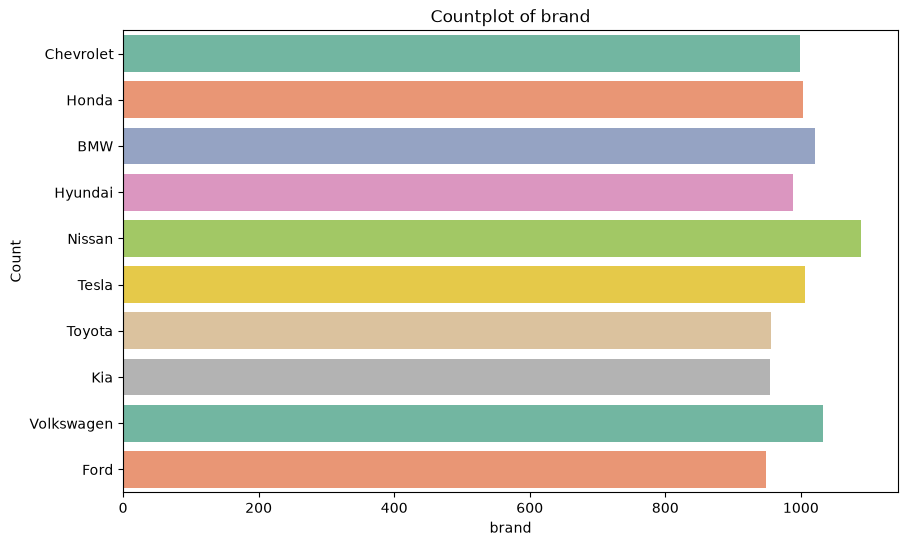

Countplot for column: transmission
-------------------


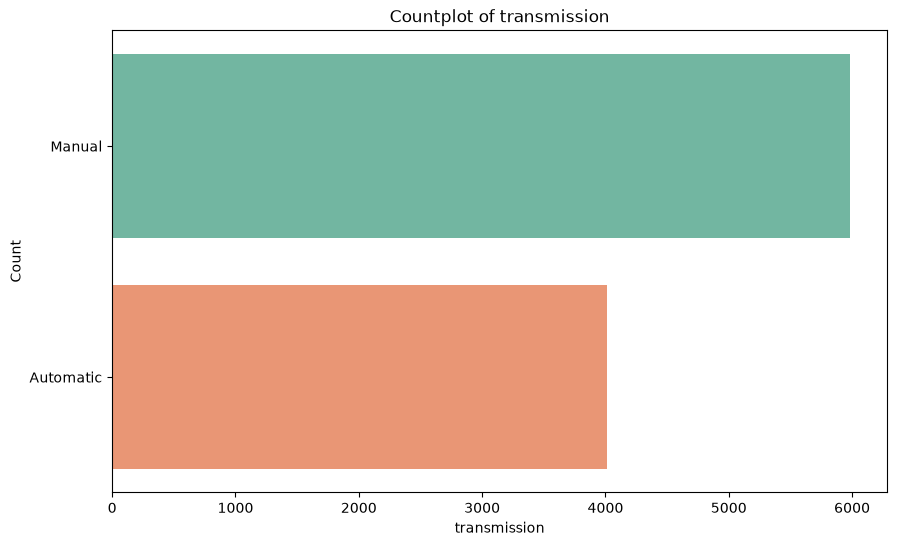

Countplot for column: color
-------------------


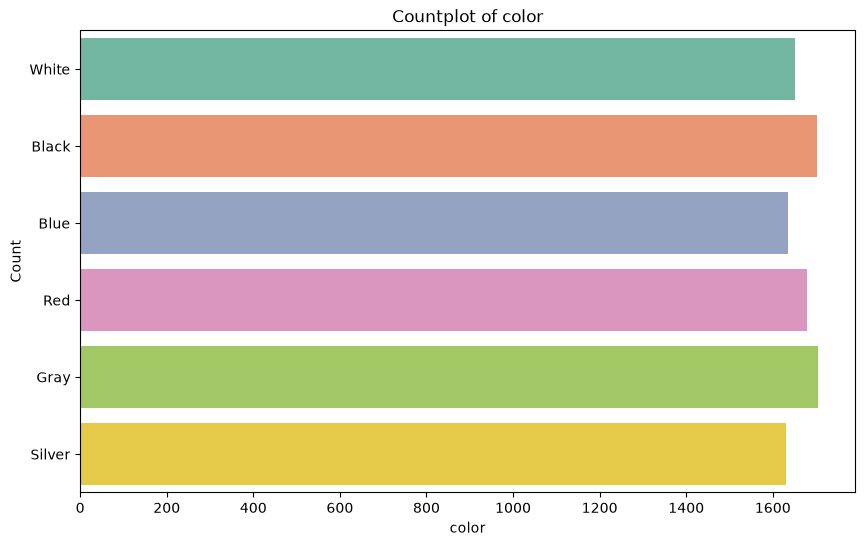

Countplot for column: service_history
-------------------


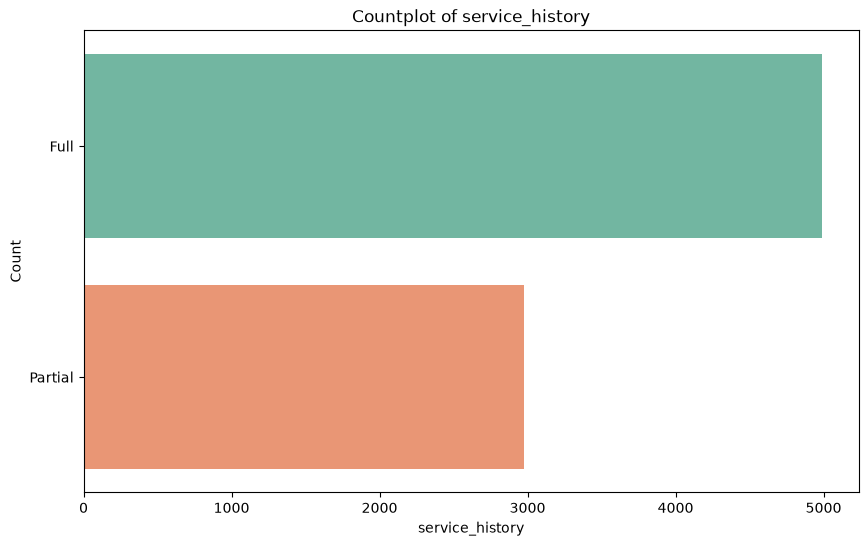

Countplot for column: insurance_valid
-------------------


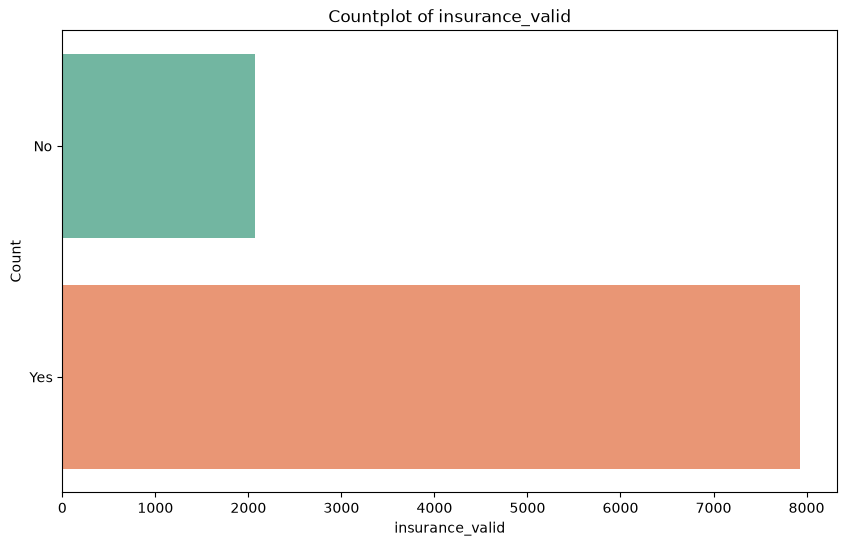

In [133]:
for column in data.select_dtypes(include=['object']).columns:
    print(f"Countplot for column: {column}")
    print('-------------------')
    plt.figure(figsize=(10, 6))
    sns.countplot(data[column], palette='Set2')
    plt.title(f"Countplot of {column}")
    plt.xlabel(f"{column}")
    plt.ylabel("Count")
    plt.show()

In [134]:
hihg=data.groupby("make_year")["price_usd"].max()
hihg.sort_values(ascending=False)

make_year
2015    17647.63
2013    17155.52
2018    16945.60
2002    16886.44
2016    16826.37
2021    16785.48
2022    16765.07
2017    16239.17
2014    16143.99
2020    16059.59
2023    15634.51
2011    15634.08
2009    15539.15
2007    15509.27
2005    15335.07
2001    15318.11
2019    15305.02
2010    14944.03
2012    14922.94
2006    14805.61
2004    14323.29
2008    14271.58
2000    13869.47
1997    13482.86
1996    13373.14
2003    13287.12
1999    13030.92
1998    12752.16
1995    12076.51
Name: price_usd, dtype: float64

## outlier detection


Boxplot for column: make_year


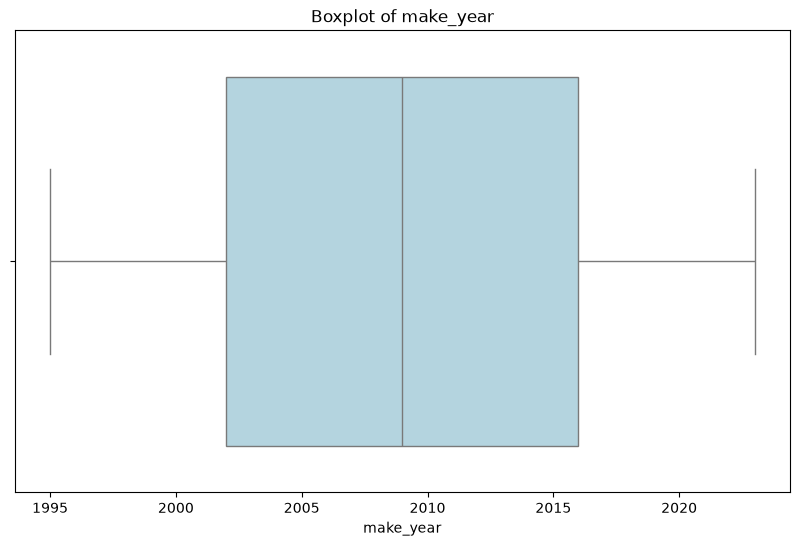

Boxplot for column: mileage_kmpl


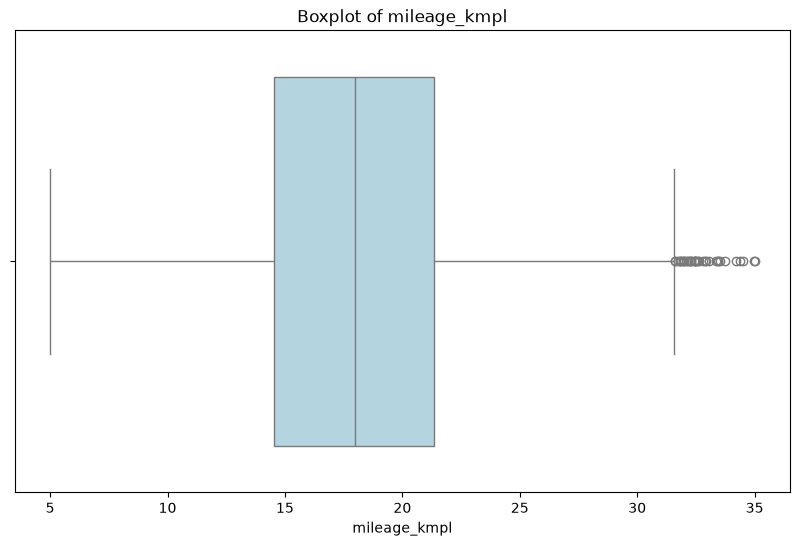

Boxplot for column: engine_cc


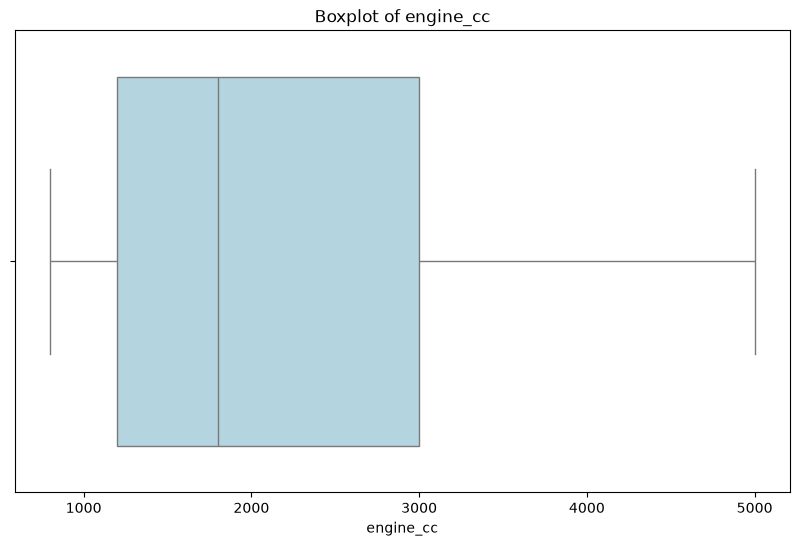

Boxplot for column: owner_count


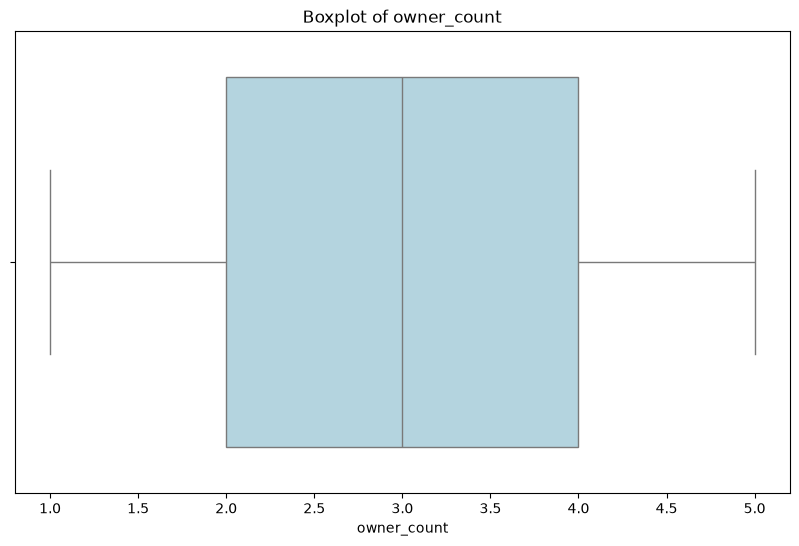

Boxplot for column: price_usd


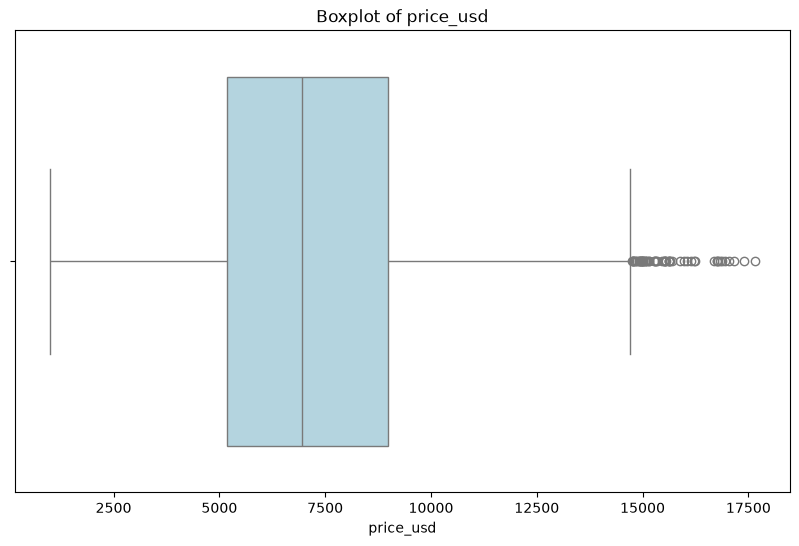

Boxplot for column: accidents_reported


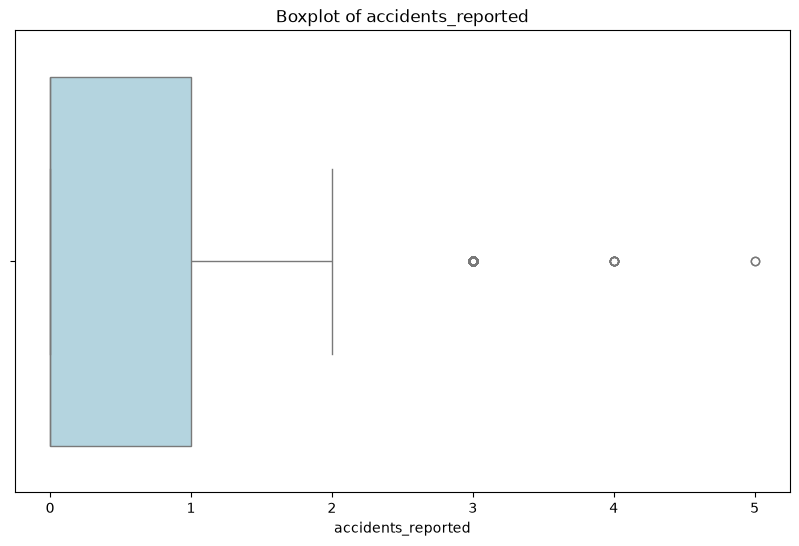

In [135]:
for col in data.select_dtypes(include=['number']).columns:
    print(f"Boxplot for column: {col}")
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=data[col], color='lightblue')
    plt.title(f"Boxplot of {col}")
    plt.xlabel(f"{col}")
    plt.show()

In [136]:
for col in data.select_dtypes(include=['number']).columns:  
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    print(f'q1: {q1}')
    print(f'q3: {q3}')
    print(f'iqr: {iqr}')
    print(f'lower_bound: {lower_bound}')
    print(f'upper_bound: {upper_bound}')
    print(f"Number of outliers in '{col}': {outliers.shape[0]}")   
    print(outliers)
    print("----------------------------------------------------------------") 

q1: 2002.0
q3: 2016.0
iqr: 14.0
lower_bound: 1981.0
upper_bound: 2037.0
Number of outliers in 'make_year': 0
Empty DataFrame
Columns: [make_year, mileage_kmpl, engine_cc, fuel_type, owner_count, price_usd, brand, transmission, color, service_history, accidents_reported, insurance_valid]
Index: []
----------------------------------------------------------------
q1: 14.54
q3: 21.3525
iqr: 6.8125
lower_bound: 4.321249999999999
upper_bound: 31.57125
Number of outliers in 'mileage_kmpl': 36
      make_year  mileage_kmpl  engine_cc fuel_type  owner_count  price_usd  \
306        1997         31.84       3000    Diesel            3    7329.53   
668        2013         33.07       1000    Petrol            4    6671.08   
1422       1995         33.45       5000    Petrol            2   11062.77   
1445       2002         32.17       1500    Diesel            2    7127.98   
1462       2017         32.08       5000    Petrol            1   16239.17   
1604       2016         32.46        800 

## outlier columns   And null Values

#### 1. price_usd 58
#### 2. accidents_reported 130
#### 3. mileage_kmpl  36
#### 4. service_history NULL Values is present 2030

In [ ]:
data['service_history'].

### Bivariate Analysis 

In [137]:
numerical_columns = data.select_dtypes(include=['number']).columns
categorical_columns = data.select_dtypes(include=['object']).columns

In [138]:
numerical_columns 

Index(['make_year', 'mileage_kmpl', 'engine_cc', 'owner_count', 'price_usd',
       'accidents_reported'],
      dtype='str')

In [ ]:
data[]

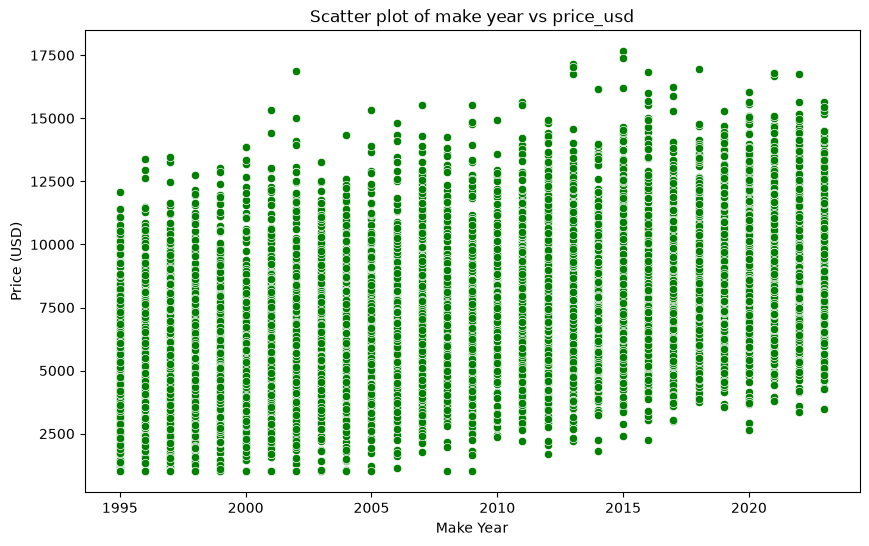

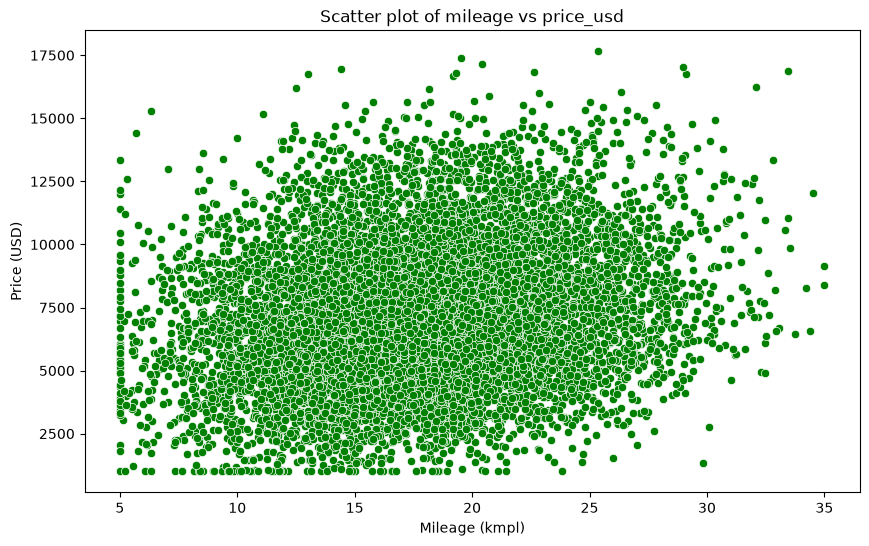

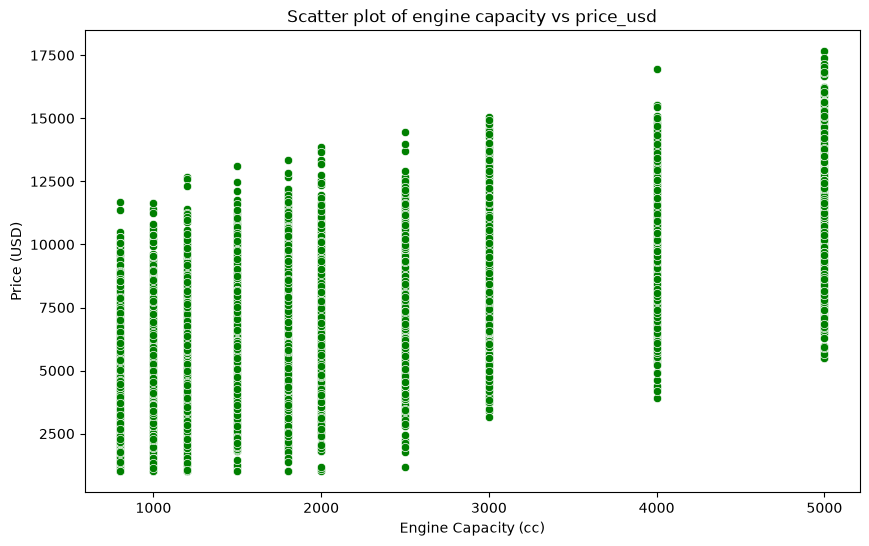

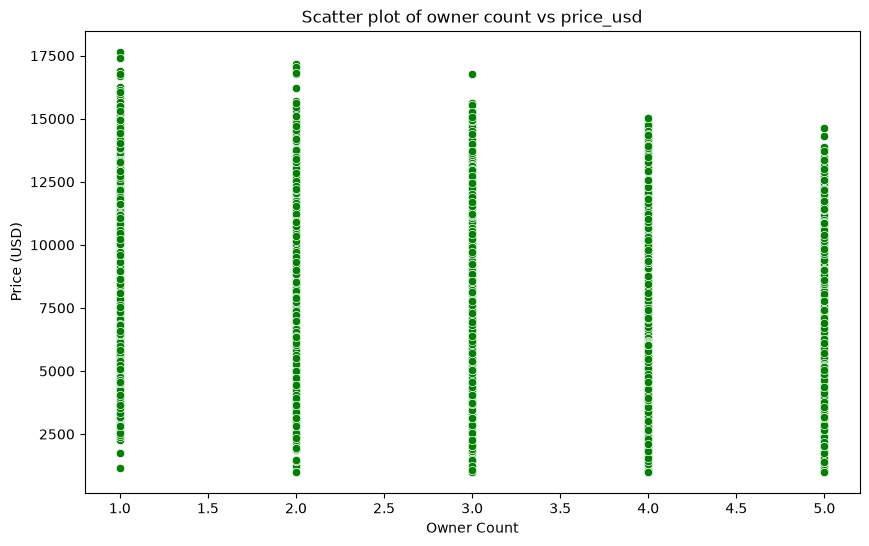

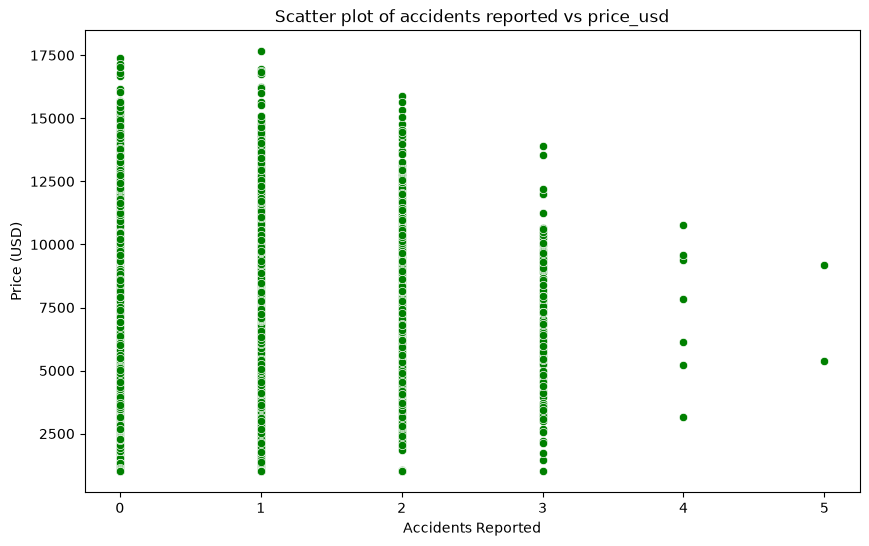

In [139]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data['make_year'], y=data['price_usd'], color='green')
plt.title("Scatter plot of make year vs price_usd")
plt.xlabel("Make Year")
plt.ylabel("Price (USD)")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=data['mileage_kmpl'], y=data['price_usd'], color='green')
plt.title("Scatter plot of mileage vs price_usd")
plt.xlabel("Mileage (kmpl)")
plt.ylabel("Price (USD)")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=data['engine_cc'], y=data['price_usd'], color='green')
plt.title("Scatter plot of engine capacity vs price_usd")
plt.xlabel("Engine Capacity (cc)")
plt.ylabel("Price (USD)")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=data['owner_count'], y=data['price_usd'], color='green')
plt.title("Scatter plot of owner count vs price_usd")
plt.xlabel("Owner Count")
plt.ylabel("Price (USD)")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=data['accidents_reported'], y=data['price_usd'], color='green')
plt.title("Scatter plot of accidents reported vs price_usd")
plt.xlabel("Accidents Reported")
plt.ylabel("Price (USD)")
plt.show()



In [140]:
data[numerical_columns].corr()

,make_year,mileage_kmpl,engine_cc,owner_count,price_usd,accidents_reported
make_year,1.000000,-0.013167,-0.017912,-0.021550,0.432603,-0.005151
mileage_kmpl,-0.013167,1.000000,-0.003222,-0.008310,0.211971,0.004567
engine_cc,-0.017912,-0.003222,1.000000,-0.000358,0.678161,-0.007750
owner_count,-0.021550,-0.008310,-0.000358,1.000000,-0.262266,-0.009365
price_usd,0.432603,0.211971,0.678161,-0.262266,1.000000,-0.001461
accidents_reported,-0.005151,0.004567,-0.007750,-0.009365,-0.001461,1.000000


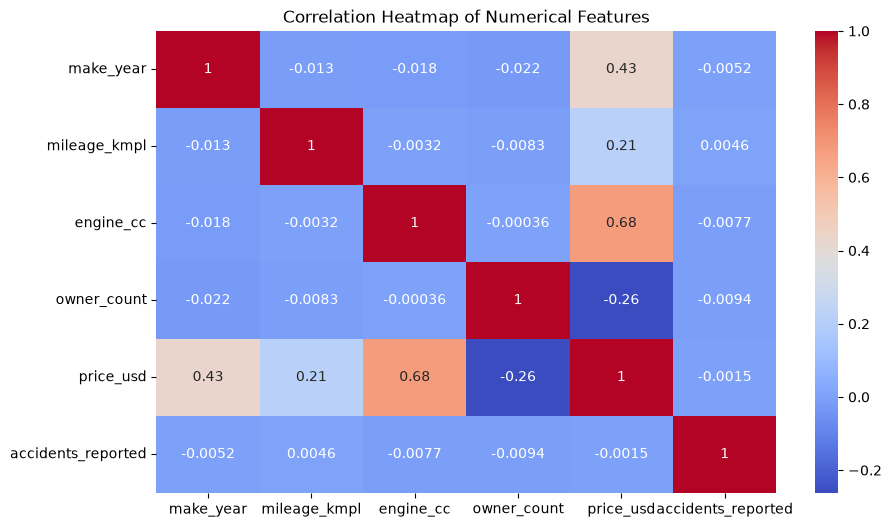

In [141]:
plt.figure(figsize=(10, 6))
sns.heatmap(data[numerical_columns].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

### Now is checking the correlation between categorical features and target using the anova test


In [142]:
categorical_columns 

Index(['fuel_type', 'brand', 'transmission', 'color', 'service_history',
       'insurance_valid'],
      dtype='str')

In [143]:
for col in categorical_columns:
    print(f"\nValue counts for column '{col}':")
    print(f"{col}: {data[col].unique()}")
    print(f"Number of unique values in column '{col}': {data[col].nunique()}")
    print("--------------------------------------------------")


Value counts for column 'fuel_type':
fuel_type: <ArrowStringArray>
['Petrol', 'Diesel', 'Electric']
Length: 3, dtype: str
Number of unique values in column 'fuel_type': 3
--------------------------------------------------

Value counts for column 'brand':
brand: <ArrowStringArray>
[ 'Chevrolet',      'Honda',        'BMW',    'Hyundai',     'Nissan',
      'Tesla',     'Toyota',        'Kia', 'Volkswagen',       'Ford']
Length: 10, dtype: str
Number of unique values in column 'brand': 10
--------------------------------------------------

Value counts for column 'transmission':
transmission: <ArrowStringArray>
['Manual', 'Automatic']
Length: 2, dtype: str
Number of unique values in column 'transmission': 2
--------------------------------------------------

Value counts for column 'color':
color: <ArrowStringArray>
['White', 'Black', 'Blue', 'Red', 'Gray', 'Silver']
Length: 6, dtype: str
Number of unique values in column 'color': 6
--------------------------------------------------

V

In [144]:
Petrol=data[data['fuel_type']=='Petrol']['price_usd']
Diesel=data[data['fuel_type']=='Diesel']['price_usd']
Electric=data[data['fuel_type']=='Electric']['price_usd']

f_stat, p_value = f_oneway(Petrol, Diesel, Electric)
if p_value < 0.05:
    print("There is a significant difference in the mean price_usd among the fuel types (Petrol, Diesel, Electric).")
else:
    print("There is no significant difference in the mean price_usd among the fuel types (Petrol, Diesel,)") 

There is a significant difference in the mean price_usd among the fuel types (Petrol, Diesel, Electric).


In [145]:

Chevrolet=data[data['brand']=='Chevrolet']['price_usd']
Honda=data[data['brand']=='Honda']['price_usd']
BMW=data[data['brand']=='BMW']['price_usd']
Hyundai=data[data['brand']=='Hyundai']['price_usd']
Nissan=data[data['brand']=='Nissan']['price_usd']
Tesla=data[data['brand']=='Tesla']['price_usd']
Toyota=data[data['brand']=='Toyota']['price_usd']
Kia=data[data['brand']=='Kia']['price_usd']
Volkswagen=data[data['brand']=='Volkswagen']['price_usd']
Ford=data[data['brand']=='Ford']['price_usd']

f_stat, p_value = f_oneway(Chevrolet, Honda, BMW, Hyundai, Nissan, Tesla, Toyota, Kia, Volkswagen, Ford)
if p_value < 0.05:
    print("There is a significant difference in the mean price_usd among the car brands.")
else:
    print("There is no significant difference in the mean price_usd among the car brands.")   

There is no significant difference in the mean price_usd among the car brands.


In [146]:
['Manual', 'Automatic']

manual=data[data['transmission']=='Manual']['price_usd']
automatic=data[data['transmission']=='Automatic']['price_usd']
f_stat, p_value = f_oneway(manual, automatic)
if p_value < 0.05:
    print("There is a significant difference in the mean price_usd between Manual and Automatic transmissions.")
else:
    print("There is no significant difference in the mean price_usd between Manual and Automatic transmissions.")    

There is no significant difference in the mean price_usd between Manual and Automatic transmissions.


In [147]:
['No', 'Yes']

no_accidents=data[data['accidents_reported']=='No']['price_usd']
yes_accidents=data[data['accidents_reported']=='Yes']['price_usd']
f_stat , p_value = f_oneway(no_accidents, yes_accidents)
if p_value < 0.05:
   
    print("There is a significant difference in the mean price_usd between cars with and without accidents.")
else:
    print("There is no significant difference in the mean price_usd between cars with and without accidents.")

There is no significant difference in the mean price_usd between cars with and without accidents.


## Data preporcessing

In [148]:
data['service_history']=data['service_history'].fillna("unknown")

In [149]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           10000 non-null  int64  
 1   mileage_kmpl        10000 non-null  float64
 2   engine_cc           10000 non-null  int64  
 3   fuel_type           10000 non-null  str    
 4   owner_count         10000 non-null  int64  
 5   price_usd           10000 non-null  float64
 6   brand               10000 non-null  str    
 7   transmission        10000 non-null  str    
 8   color               10000 non-null  str    
 9   service_history     10000 non-null  str    
 10  accidents_reported  10000 non-null  int64  
 11  insurance_valid     10000 non-null  str    
dtypes: float64(2), int64(4), str(6)
memory usage: 1.2 MB


## Encoding

In [150]:
data[categorical_columns]



,fuel_type,brand,transmission,color,service_history,insurance_valid
0,Petrol,Chevrolet,Manual,White,unknown,No
1,Petrol,Honda,Manual,Black,unknown,Yes
2,Diesel,BMW,Automatic,Black,Full,Yes
3,Petrol,Hyundai,Manual,Blue,Full,Yes
4,Petrol,Nissan,Automatic,Red,Full,Yes
...,...,...,...,...,...,...
9995,Petrol,Hyundai,Manual,Silver,unknown,Yes
9996,Diesel,Honda,Manual,Gray,Full,Yes
9997,Diesel,Kia,Manual,Black,Full,Yes
9998,Petrol,BMW,Automatic,Blue,Full,Yes


In [151]:
data=pd.get_dummies(data,columns=['brand'],dtype=int)

In [152]:
data=pd.get_dummies(data,columns=['fuel_type'],dtype=int)

In [153]:
data=pd.get_dummies(data,columns=['transmission'],dtype=int)

In [154]:
data=pd.get_dummies(data,columns=['service_history'],dtype=int)

In [155]:
encode = LabelEncoder()
data['insurance_valid']=encode.fit_transform(data['insurance_valid'])

In [156]:
data=pd.get_dummies(data,columns=['color'],dtype=int)

In [157]:
data

,make_year,mileage_kmpl,engine_cc,owner_count,price_usd,accidents_reported,insurance_valid,brand_BMW,brand_Chevrolet,brand_Ford,...,transmission_Manual,service_history_Full,service_history_Partial,service_history_unknown,color_Black,color_Blue,color_Gray,color_Red,color_Silver,color_White
0,2001,8.17,4000,4,8587.64,0,0,0,1,0,...,1,0,0,1,0,0,0,0,0,1
1,2014,17.59,1500,4,5943.50,0,1,0,0,0,...,1,0,0,1,1,0,0,0,0,0
2,2023,18.09,2500,5,9273.58,1,1,1,0,0,...,0,1,0,0,1,0,0,0,0,0
3,2009,11.28,800,1,6836.24,0,1,0,0,0,...,1,1,0,0,0,1,0,0,0,0
4,2005,12.23,1000,2,4625.79,0,1,0,0,0,...,0,1,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1996,15.25,1500,2,5498.71,0,1,0,0,0,...,1,0,0,1,0,0,0,0,1,0
9996,1997,14.45,5000,1,9588.31,0,1,0,0,0,...,1,1,0,0,0,0,1,0,0,0
9997,2002,19.41,1000,4,4557.10,0,1,0,0,0,...,1,1,0,0,1,0,0,0,0,0
9998,2005,12.95,4000,5,7413.59,0,1,1,0,0,...,0,1,0,0,0,1,0,0,0,0


In [158]:
x =data.drop('price_usd',axis=1)
y = data['price_usd']

In [159]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [160]:
model=LinearRegression()

In [161]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](30,)","[149.3 ,123.15, 1.49,..., 58.09,-26.02, 14.77]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](30,)","['make_year','mileage_kmpl','engine_cc',...,'color_Red','color_Silver', 'color_White']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.962e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,30
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(25)


In [162]:
y_prd = model.predict(x_test)

In [163]:

mae = mean_absolute_error(y_test, y_prd)

mse = mean_squared_error(y_test, y_prd)

r2 = r2_score(y_test, y_prd)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 795.806632021497
MSE: 998909.010117446
R2 Score: 0.8743160195901889


In [164]:
train_model = model.score(x_train,y_train)
test_model = model.score(x_test,y_test)

print(f'Train Model {train_model}')
print(f'Test Model {test_model}')

Train Model 0.8709579103427314
Test Model 0.8743160195901889


In [165]:
joblib.dump(x.columns.tolist(), "columns.pkl")


['columns.pkl']

In [166]:
joblib.dump(
    encode,
    "encoder.pkl"
)

['encoder.pkl']

In [167]:
models = {
    "RandomForest":RandomForestRegressor(),
    "DecisionTreeRegressor":DecisionTreeRegressor(),
    "LinearRegression":LinearRegression(),
    "AdaBoostRegressor":AdaBoostRegressor(),
    "GradientBoostingRegressor":GradientBoostingRegressor()
}
    

In [168]:
model_score =-0
model_name = None
for key,items in models.items():
    print(f'\nModel Name {key}')
    items.fit(x_train,y_train)
    y_prd2 = items.predict(x_test)

    mae = mean_absolute_error(y_test, y_prd2)
    mse = mean_squared_error(y_test, y_prd2)
    r2 = r2_score(y_test, y_prd2)
    print("MAE:", mae)
    print("MSE:", mse)
    print("R2 Score:", r2)
    print(f'\nModel Score')
    
    train_models = items.score(x_train,y_train)
    test_models = items.score(x_test,y_test)
    print(f'model Train Score {train_models}')
    print(f'model Test Score {test_models}')

    # Linear Regression
    cv_scores = cross_val_score(items, x, y, cv=5, scoring="r2")

    print("\nCross Validation Scores:", cv_scores)
    print("Average R2 Score:", cv_scores.mean())
    print('------------------------------------------------------------------------------------')

    if r2 > model_score:
        model_score=r2
        model_name=items


    


Model Name RandomForest
MAE: 873.4779956666667
MSE: 1212509.186419012
R2 Score: 0.8474405783819233

Model Score
model Train Score 0.9782699436035102
model Test Score 0.8474405783819233

Cross Validation Scores: [0.84438225 0.84905064 0.84751878 0.85019092 0.85041197]
Average R2 Score: 0.8483109138772058
------------------------------------------------------------------------------------

Model Name DecisionTreeRegressor
MAE: 1237.9923533333333
MSE: 2456862.9114983333
R2 Score: 0.6908744371000894

Model Score
model Train Score 1.0
model Test Score 0.6908744371000894

Cross Validation Scores: [0.69054612 0.70571664 0.70603653 0.71446404 0.68766254]
Average R2 Score: 0.7008851737483078
------------------------------------------------------------------------------------

Model Name LinearRegression
MAE: 795.806632021497
MSE: 998909.010117446
R2 Score: 0.8743160195901889

Model Score
model Train Score 0.8709579103427314
model Test Score 0.8743160195901889

Cross Validation Scores: [0.86639

In [169]:
data_compare = pd.DataFrame({
    'Actaual Pradict':y_test,
    'Prdicat Value':y_prd
})
print(data_compare)

      Actaual Pradict  Prdicat Value
6252         12772.12   12082.581560
4684          6177.69    4731.403285
1731          6850.02    7036.520973
4742          3373.18    3574.408695
4521          7314.85    8004.365848
...               ...            ...
8014          6390.17    4581.543481
1074          8666.39   11195.327265
3063          4479.93    3712.287068
6487          6415.18    6231.085671
4705          8154.72    8975.824378

[3000 rows x 2 columns]


In [170]:
data[data['price_usd']==    8154.72 ]

,make_year,mileage_kmpl,engine_cc,owner_count,price_usd,accidents_reported,insurance_valid,brand_BMW,brand_Chevrolet,brand_Ford,...,transmission_Manual,service_history_Full,service_history_Partial,service_history_unknown,color_Black,color_Blue,color_Gray,color_Red,color_Silver,color_White
4705,2008,21.34,1800,4,8154.72,0,1,1,0,0,...,1,0,0,1,0,0,0,0,1,0


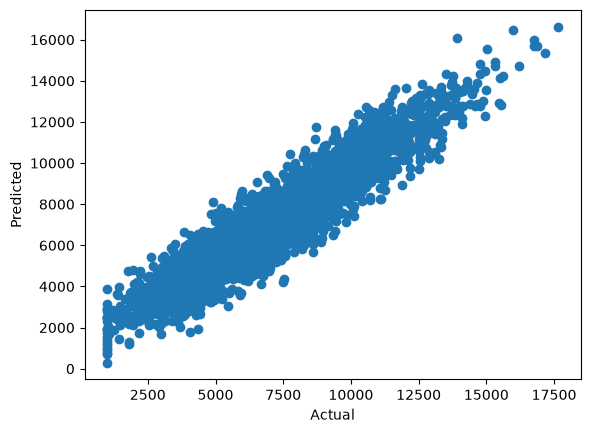

In [171]:
plt.scatter(y_test, y_prd)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [172]:
print(model_name)
print(model_score)

LinearRegression()
0.8743160195901889


In [173]:
lr_best_model = model_name

## business insight:

### 1. The cars years increase car price also increase

### 2.  The cars engine_cc decrease and price also decrese

 ### 3.Mostly petrol car highest selling and second deisal. very low selling in automatic compare the manual

 ###  4. nission car high selling in your company and second the selling Volkswagen and remaining car is modertate sales 
  

  ### 5.All car colors have good sales



  ### 6.mostly all cars insurance vaild and few cars only the invaild 

### 7.2015 cars have the highest average selling price ($17,647.63), and 2018 cars ($16,945.60).

In [174]:
numerical_columns

Index(['make_year', 'mileage_kmpl', 'engine_cc', 'owner_count', 'price_usd',
       'accidents_reported'],
      dtype='str')

In [175]:
joblib.dump(
    model,
    "model.pkl"
)

['model.pkl']